In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [7]:
# ============================================================
# 1. LOAD DATASET
# ============================================================
iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
# ============================================================
# 2. LATIH MODEL
# ============================================================
logreg = LogisticRegression(max_iter=200)
dtree = DecisionTreeClassifier(max_depth=3, random_state=42)

logreg.fit(X_train, y_train)
dtree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None



Logistic Regression
Accuracy  : 1.000
Precision : 1.000
Recall    : 1.000
F1-Score  : 1.000

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



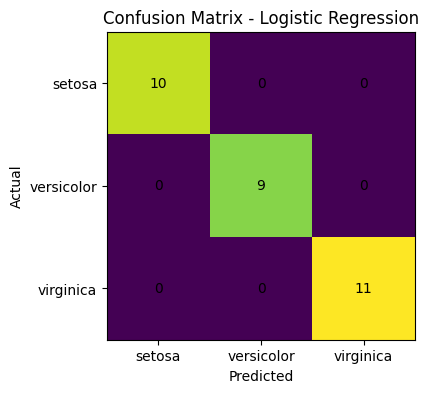


Decision Tree
Accuracy  : 1.000
Precision : 1.000
Recall    : 1.000
F1-Score  : 1.000

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



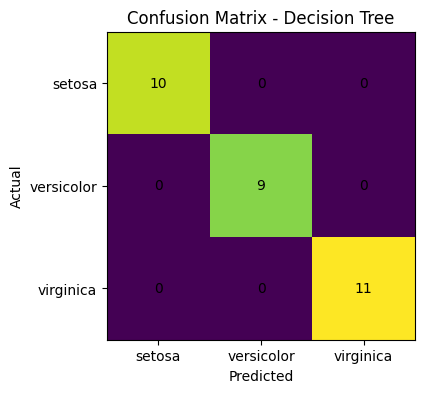

In [9]:
# ============================================================
# 3. EVALUASI MODEL
# ============================================================
models = {
    "Logistic Regression": logreg,
    "Decision Tree": dtree
}

results = []

for name, model in models.items():

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append([name, acc, precision, recall, f1])

    print("\n" + "="*60)
    print(f"{name}")
    print("="*60)

    print(f"Accuracy  : {acc:.3f}")
    print(f"Precision : {precision:.3f}")
    print(f"Recall    : {recall:.3f}")
    print(f"F1-Score  : {f1:.3f}")

    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)

    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    ))

    # ========================================================
    # Visualisasi Confusion Matrix
    # ========================================================
    plt.figure(figsize=(5,4))
    plt.imshow(cm)
    plt.title(f"Confusion Matrix - {name}")
    plt.xticks(np.arange(len(iris.target_names)), iris.target_names)
    plt.yticks(np.arange(len(iris.target_names)), iris.target_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    for i in range(len(cm)):
        for j in range(len(cm)):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.show()



TABEL PERBANDINGAN MODEL
                 Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression       1.0        1.0     1.0       1.0
1        Decision Tree       1.0        1.0     1.0       1.0


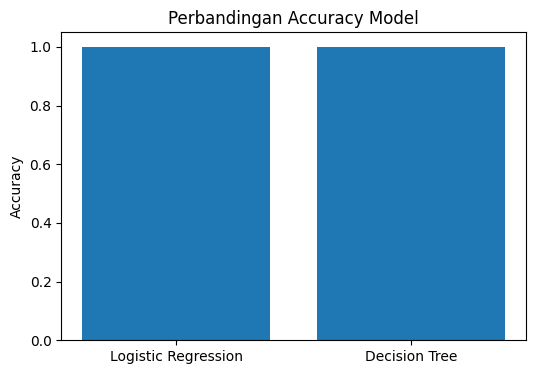

In [12]:
# ============================================================
# 4. TABEL PERBANDINGAN
# ============================================================
df_results = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"]
)

print("\n" + "="*60)
print("TABEL PERBANDINGAN MODEL")
print("="*60)
print(df_results)

# ============================================================
# 5. VISUALISASI PERBANDINGAN ACCURACY
# ============================================================
plt.figure(figsize=(6,4))
plt.bar(df_results["Model"], df_results["Accuracy"])
plt.title("Perbandingan Accuracy Model")
plt.ylabel("Accuracy")
plt.show()

In [13]:
# ============================================================
# 6. KESIMPULAN OTOMATIS
# ============================================================
print("\n" + "="*60)
print("KESIMPULAN")
print("="*60)

best_model = df_results.loc[df_results["Accuracy"].idxmax(), "Model"]
best_acc = df_results["Accuracy"].max()

print(f"Model terbaik berdasarkan accuracy adalah: {best_model}")
print(f"Dengan accuracy sebesar: {best_acc:.3f}")

print("\nAnalisis:")
print("- Logistic Regression adalah model linear yang stabil dan interpretatif.")
print("- Decision Tree mampu menangkap pola non-linear.")
print("- Pada dataset Iris yang kecil dan terpisah jelas, kedua model biasanya memiliki performa sangat tinggi.")
print("- Jika accuracy sama, Logistic Regression lebih sederhana dan lebih mudah diinterpretasikan.")

print("\n✅ Tugas Pertemuan 04 selesai.")


KESIMPULAN
Model terbaik berdasarkan accuracy adalah: Logistic Regression
Dengan accuracy sebesar: 1.000

Analisis:
- Logistic Regression adalah model linear yang stabil dan interpretatif.
- Decision Tree mampu menangkap pola non-linear.
- Pada dataset Iris yang kecil dan terpisah jelas, kedua model biasanya memiliki performa sangat tinggi.
- Jika accuracy sama, Logistic Regression lebih sederhana dan lebih mudah diinterpretasikan.

✅ Tugas Pertemuan 04 selesai.
